In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import json

cifar_10_grid_folder = Path(".") / "runs" / "first_grid" / "grid_20260528_085354"

dfs = []

for ent in cifar_10_grid_folder.iterdir():
    
    if not ent.name.endswith(".json"):
        continue

    with open(ent, "r") as f:
        data = json.load(f)


    
    args = ent.stem.split("_")[:-1]
    specs = {}
    for i in range(0, len(args), 2):
        specs[args[i]] = int(args[i + 1])


    df = pd.DataFrame(data)
    df["epoch"] = np.arange(len(df))
    df["run"] = ent.stem
    for k, v in specs.items():
        df[f"{k}_param"] = v
        
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
del dfs

assert df.groupby("run")["epoch"].max().unique().size == 1
df_last_epoch = df[df["epoch"] == df["epoch"].max()]

df.sample(3)

,validation_loss,validation_accuracy_metric,validation_ce_loss,validation_div_loss,validation_kl_fig2,validation_load_distribution_loss,validation_power_entropy_fig1,validation_prediction_entropy_fig1,loss,ce_loss,div_loss,load_distribution_loss,epoch,run,predictors_param,delegators_param,pwidth_param,dwidth_param
7324,2.297417,0.445801,2.295001,-0.0,7.291341,0.002417,0.888266,0.109784,2.153484,2.151089,0.0,0.002395,24,predictors_8_delegators_4_pwidth_8_dwidth_32_m...,8,4,8,32
3065,2.138346,0.479004,2.137360,-0.0,7.448248,0.000986,0.961664,0.133943,1.945038,1.944117,0.0,0.000922,15,predictors_8_delegators_32_pwidth_64_dwidth_4_...,8,32,64,4
5952,2.478419,0.385742,2.478365,-0.0,1.154928,0.000054,0.999771,0.548958,2.483345,2.483319,0.0,0.000026,2,predictors_4_delegators_4_pwidth_64_dwidth_4_m...,4,4,64,4


In [19]:
df["validation_accuracy_metric"].describe()

count    9600.000000
mean        0.450872
std         0.065545
min         0.177734
25%         0.416016
50%         0.467773
75%         0.498535
max         0.558594
Name: validation_accuracy_metric, dtype: float64

<Axes: xlabel='delegators_param', ylabel='validation_accuracy_metric'>

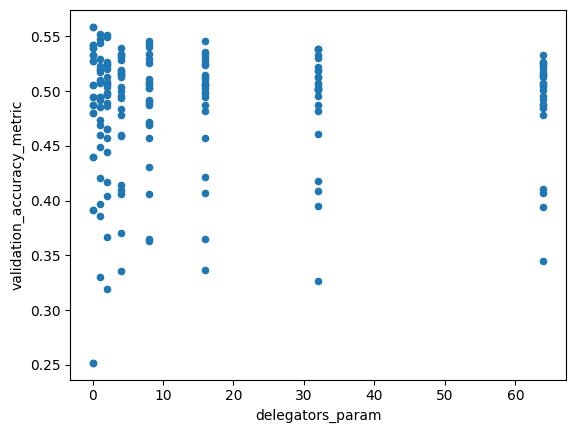

In [25]:
df_last_epoch.plot.scatter("delegators_param", "validation_accuracy_metric")

In [ ]:
import optuna
from optuna.importance import FanovaImportanceEvaluator

# 1. Create a dummy study
study = optuna.create_study(direction="minimize") # or "maximize"

# 2. Feed your grid search data into the study
# Replace this loop with your actual dataframe/grid results
for _, row in df_last_epoch.iterrows():
    trial = optuna.trial.create_trial(
        params={"learning_rate": row["lr"], "depth": row["depth"]}, # your params
        distributions={
            "learning_rate": optuna.distributions.FloatDistribution(0.01, 0.1),
            "depth": optuna.distributions.IntDistribution(3, 10)
        },
        value=row["loss"] # your variable of interest
    )
    study.add_trial(trial)

# 3. Compute and plot fANOVA importance
importance = optuna.importance.get_param_importances(
    study, evaluator=FanovaImportanceEvaluator()
)
print(importance)